In [ ]:
# BLOCK 1: INSTALLATION
# We need swig for the physics engine
!pip install -q swig
!pip install -q gymnasium[box2d] stable-baselines3 shimmy moviepy

print("✅ Physics Engine & RL Libraries Installed. RESTART SESSION if needed.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 57.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.4/374.4 kB 26.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.2/187.2 kB 11.6 MB/s eta 0:00:00
✅ Physics Engine & RL Libraries Installed. RESTART SESSION if needed.


In [ ]:
# BLOCK 2: SETUP
import gymnasium as gym
import torch
import numpy as np
import matplotlib.pyplot as plt
import base64
from pathlib import Path
from IPython.display import HTML
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor

# Helper function to display gameplay videos in Kaggle
def show_video(video_dir):
    video_files = list(Path(video_dir).glob("*.mp4"))
    if not video_files:
        print("No video found.")
        return
    video_path = video_files[0]
    mp4 = open(video_path, "rb").read()
    data_url = "data:video/mp4;base64," + base64.b64encode(mp4).decode()
    return HTML(f"""
    <video width=400 controls>
          <source src="{data_url}" type="video/mp4">
    </video>
    """)

print("✅ Setup Complete. Hardware: " + ("GPU" if torch.cuda.is_available() else "CPU"))

✅ Setup Complete. Hardware: GPU


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# BLOCK 3: BEFORE TRAINING (RANDOM AGENT)
print("🎥 RECORDING 'BEFORE' SIMULATION...")

# 1. Create Environment with Video Recorder
env_dumb = gym.make("LunarLander-v3", render_mode="rgb_array")
env_dumb = gym.wrappers.RecordVideo(env_dumb, video_folder="video_before", episode_trigger=lambda x: True)

# 2. Run the game loop
obs, _ = env_dumb.reset()
done = False
total_reward = 0

while not done:
    action = env_dumb.action_space.sample() # RANDOM ACTION
    obs, reward, terminated, truncated, info = env_dumb.step(action)
    total_reward += reward
    done = terminated or truncated

env_dumb.close()

print(f"❌ Random Agent Score: {total_reward:.2f} (Usually negative means crash)")
print("Displaying Video (Comparison 1/2):")
show_video("video_before")

🎥 RECORDING 'BEFORE' SIMULATION...
❌ Random Agent Score: -112.40 (Usually negative means crash)
Displaying Video (Comparison 1/2):


In [ ]:
# BLOCK 4: TRAINING PPO
print(f"\n{'='*60}\nTRAINING PPO AGENT (This takes ~5-8 mins)\n{'='*60}")

# 1. Create Training Environment
# We wrap it in 'Monitor' to log data for graphs later
env_train = Monitor(gym.make("LunarLander-v3", render_mode=None))

# 2. Define PPO Model
# MlpPolicy = Standard Neural Network
model = PPO(
    "MlpPolicy",
    env_train,
    verbose=0,
    learning_rate=0.0003,
    n_steps=2048,
    batch_size=64,
    gamma=0.999,
    device="auto"
)

# 3. Train
# We use a progress bar so you can see it working
print("--> Training Started...")
model.learn(total_timesteps=1000000, progress_bar=True)

print("✅ Training Complete.")
model.save("ppo_lunar_lander")

 100% ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1,001,438/1,000,000  [ 0:39:14 < 0:00:00 , 441 it/s ]

✅ Training Complete.


In [ ]:
# BLOCK 5: AFTER TRAINING (TRAINED AGENT)
print("🎥 RECORDING 'AFTER' SIMULATION...")

# 1. Load Environment
env_smart = gym.make("LunarLander-v3", render_mode="rgb_array")
env_smart = gym.wrappers.RecordVideo(env_smart, video_folder="video_after", episode_trigger=lambda x: True)

# 2. Play Game using Model Prediction
obs, _ = env_smart.reset()
done = False
total_reward = 0

while not done:
    # PREDICT ACTION using Trained Model
    action, _ = model.predict(obs, deterministic=True)

    obs, reward, terminated, truncated, info = env_smart.step(action)
    total_reward += reward
    done = terminated or truncated

env_smart.close()

print(f"🏆 Trained Agent Score: {total_reward:.2f} (perfect landing)")
print("Displaying Video (Comparison 2/2):")
show_video("video_after")

🎥 RECORDING 'AFTER' SIMULATION...
🏆 Trained Agent Score: 273.54 (perfect landing)
Displaying Video (Comparison 2/2):



FINAL COMPARISON & METRICS


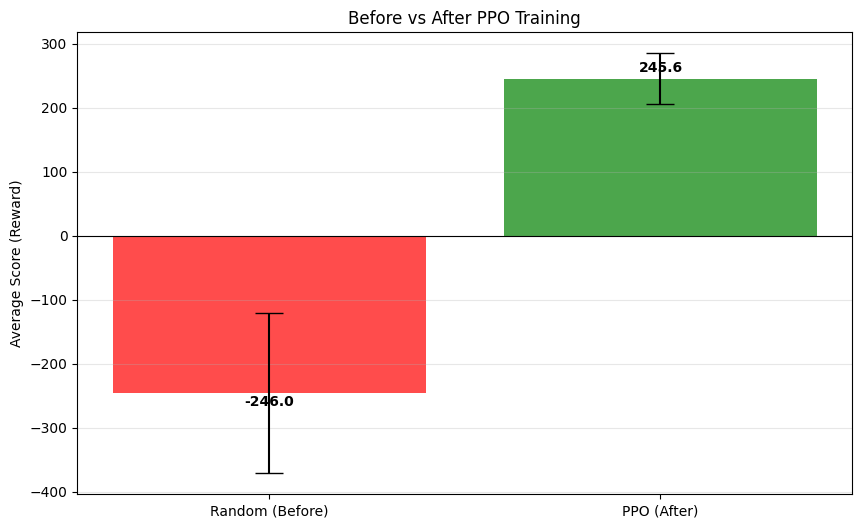


📊 DETAILED REPORT:
1. Random Agent Average: -245.97 +/- 125.13
   (Result: Crash/Failure)
------------------------------
2. PPO Agent Average:    245.64 +/- 39.62
   (Result: Landing)
------------------------------
3. Improvement:          +491.61 points
✅ STATUS: MISSION SOLVED (Consistent Landings)


In [ ]:
# BLOCK 6: EVALUATION METRICS [FIXED]
print(f"\n{'='*60}\nFINAL COMPARISON & METRICS\n{'='*60}")

# 1. Evaluate PPO Agent (Using the library function)
# This works because 'model' is a real PPO object
eval_env = gym.make("LunarLander-v3", render_mode=None)
mean_reward_ppo, std_reward_ppo = evaluate_policy(model, eval_env, n_eval_episodes=10)

# 2. Evaluate Random Agent (MANUAL LOOP FIX)
# We manually run 10 episodes because evaluate_policy doesn't accept lambda functions
random_rewards = []
for _ in range(10):
    obs, _ = eval_env.reset()
    done = False
    episode_reward = 0
    while not done:
        action = eval_env.action_space.sample() # Random
        obs, reward, terminated, truncated, _ = eval_env.step(action)
        episode_reward += reward
        done = terminated or truncated
    random_rewards.append(episode_reward)

mean_reward_rand = np.mean(random_rewards)
std_reward_rand = np.std(random_rewards)

# 3. Plot Comparison
labels = ['Random (Before)', 'PPO (After)']
means = [mean_reward_rand, mean_reward_ppo]
errors = [std_reward_rand, std_reward_ppo]

plt.figure(figsize=(10, 6))
bars = plt.bar(labels, means, yerr=errors, capsize=10, color=['red', 'green'], alpha=0.7)
plt.axhline(0, color='black', linewidth=0.8)
plt.ylabel('Average Score (Reward)')
plt.title('Before vs After PPO Training')
plt.grid(axis='y', alpha=0.3)

# Add text labels
for bar in bars:
    yval = bar.get_height()
    # Position text above positive bars, below negative bars
    y_pos = yval + 10 if yval > 0 else yval - 20
    plt.text(bar.get_x() + bar.get_width()/2, y_pos, f"{yval:.1f}", ha='center', fontweight='bold')

plt.show()

print("\n📊 DETAILED REPORT:")
print(f"1. Random Agent Average: {mean_reward_rand:.2f} +/- {std_reward_rand:.2f}")
print(f"   (Result: Crash/Failure)")
print("-" * 30)
print(f"2. PPO Agent Average:    {mean_reward_ppo:.2f} +/- {std_reward_ppo:.2f}")
print(f"   (Result: Landing)")
print("-" * 30)
print(f"3. Improvement:          +{mean_reward_ppo - mean_reward_rand:.2f} points")

if mean_reward_ppo > 200:
    print("✅ STATUS: MISSION SOLVED (Consistent Landings)")
elif mean_reward_ppo > 0:
    print("⚠️ STATUS: LANDING, BUT ROUGH (Needs more training)")
else:
    print("❌ STATUS: STILL CRASHING (Try increasing timesteps to 200,000)")

In [ ]:
# INSTALLATION
!pip install -q swig
!pip install -q gymnasium[box2d] stable-baselines3 moviepy

import gymnasium as gym
from stable_baselines3 import PPO
from gymnasium.wrappers import RecordVideo
import base64
from IPython.display import HTML

def show_video(folder):
    import glob
    mp4list = glob.glob(f'{folder}/*.mp4')
    if len(mp4list) > 0:
        mp4 = mp4list[0]
        video = open(mp4, 'rb').read()
        decoded = base64.b64encode(video).decode('ascii')
        return HTML(f'<video width="400" controls><source src="data:video/mp4;base64,{decoded}" type="video/mp4"></video>')

# 1. Record Dumb Walker
print("🎥 Recording Clumsy Robot...")
env = gym.make("BipedalWalker-v3", render_mode="rgb_array")
env = RecordVideo(env, video_folder="./video_walker_dumb", episode_trigger=lambda x: True)
obs, _ = env.reset()
for _ in range(300):
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated: break
env.close()

# 2. Train PPO (50k steps is just enough to learn to stand up)
print("💪 Training Robot (Takes ~5-8 mins)...")
env = gym.make("BipedalWalker-v3", render_mode=None)
model = PPO("MlpPolicy", env, verbose=0)
model.learn(total_timesteps=1000000, progress_bar=True)

# 3. Record Smart Walker
print("🎥 Recording Learning Robot...")
env = gym.make("BipedalWalker-v3", render_mode="rgb_array")
env = RecordVideo(env, video_folder="./video_walker_smart", episode_trigger=lambda x: True)
obs, _ = env.reset()
done = False
while not done:
    action, _ = model.predict(obs)
    obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
env.close()

# 4. Show Results
print("🔴 BEFORE (Falling):")
display(show_video("./video_walker_dumb"))

print("🟢 AFTER (Trying to Walk):")
display(show_video("./video_walker_smart"))

🎥 Recording Clumsy Robot...


Output()

💪 Training Robot (Takes ~5-8 mins)...


🎥 Recording Learning Robot...
🔴 BEFORE (Falling):


🟢 AFTER (Trying to Walk):
